# Customer Revenue Prediction

This notebook is the project review notebook for predicting future customer revenue from the 2016-2017 transaction history. The reusable code lives in `src/proj1`, while the notebook keeps the analysis trail: EDA, feature design, model trials, diagnostics, validation, submissions, and the final discussion.

The goal here is not to hide the work behind a clean pipeline. The goal is to make the project easy to review: what was checked, what worked, what failed, and why the final submission was chosen.


In [2]:
# ruff: noqa: E402
from pathlib import Path
import sys
import warnings

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

warnings.filterwarnings("ignore")

from IPython.display import display
import numpy as np
import pandas as pd

from proj1.config import ProjectPaths, load_project_config
from proj1.diagnostics import (
    calibration_by_actual_bins,
    error_by_actual_thresholds,
    error_decomposition,
    feature_importance_table,
    high_value_feature_comparison,
    prediction_distribution_table,
    submission_summary,
    variance_by_prediction_bin,
    zero_threshold_table,
)
from proj1.metrics import describe_target, results_frame
from proj1.modeling import (
    make_submission,
    run_improved_xgboost_trials,
    run_mae_aligned_hurdle,
    save_submission,
)
from proj1.workflow import (
    build_features,
    generate_submission_files,
    load_project_data,
    prepare_modeling_workflow,
    run_baseline_models,
    run_champion_cv,
    run_eda,
    run_main_models,
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)

# IMPORTANT: Change this to point to your original data directory!!!
DATA_DIR = PROJECT_ROOT.parents[1] / "data"

paths = ProjectPaths.from_root(PROJECT_ROOT, data_dir=DATA_DIR)
# paths = ProjectPaths.from_env(PROJECT_ROOT / ".env", root=PROJECT_ROOT)

CONFIG_FILE = PROJECT_ROOT / "config" / "default.toml"
LOCAL_CONFIG_FILE = PROJECT_ROOT / "config" / "local.toml"
config = load_project_config(CONFIG_FILE, LOCAL_CONFIG_FILE)

paths.ensure_output_dirs()
display(paths)
config


ProjectPaths(root=PosixPath('/Users/xinran_joyce/Desktop/KU Leuven/Courses & Exams/Second year_2 Semester/Advanced Analytics in Business/Assignment/Assignment_1/kul-advanced-analytics/proj1'), data_dir=PosixPath('/Users/xinran_joyce/Desktop/KU Leuven/Courses & Exams/Second year_2 Semester/Advanced Analytics in Business/Assignment/Assignment_1/data'), features_dir=PosixPath('/Users/xinran_joyce/Desktop/KU Leuven/Courses & Exams/Second year_2 Semester/Advanced Analytics in Business/Assignment/Assignment_1/kul-advanced-analytics/proj1/data/features'), plots_dir=PosixPath('/Users/xinran_joyce/Desktop/KU Leuven/Courses & Exams/Second year_2 Semester/Advanced Analytics in Business/Assignment/Assignment_1/kul-advanced-analytics/proj1/plots'), submissions_dir=PosixPath('/Users/xinran_joyce/Desktop/KU Leuven/Courses & Exams/Second year_2 Semester/Advanced Analytics in Business/Assignment/Assignment_1/kul-advanced-analytics/proj1/submissions'), report_dir=PosixPath('/Users/xinran_joyce/Desktop/K

ProjectConfig(data=DataConfig(train_filename='customer_clv_train.csv', test_filename='customer_clv_test.csv', transactions_filename='transactions_2016_2017.csv', raw_feature_filename='customer_features_v4.parquet', clean_feature_filename='customer_features_v4_clean.parquet', submission_filename='v01_champion_xgb_mae_pp.csv', customer_id_col='cust_id', target_col='revenue_2018_2019', prediction_col='prediction', transaction_parse_dates=['order_date', 'pack_date'], required_transaction_columns=['cust_id', 'sale_id', 'prod_id', 'order_date', 'pack_date', 'sale_revenue'], transaction_defaults={'prod_size': 'nan', 'returned_to_shop_id': 'nan', 'sale_discount_applied': 0.0, 'prod_brand': 'unknown', 'prod_season': 'nan', 'prod_color': 'unknown', 'prod_type_1': 'unknown', 'prod_type_3': 'unknown', 'prod_type_4': 'unknown', 'prod_type_5': 'unknown', 'prod_heel': 'nan', 'prod_material': 'nan', 'prod_print': 'nan', 'prod_clasp': 'nan', 'prod_comfort_sole': 'nan', 'prod_comfort_wear': 'nan', 'prod

## Run Settings

These switches keep the notebook reproducible while making it possible to skip the slower model trials during drafting. The default values come from `config/default.toml`; local changes can go into `config/local.toml` or be overwritten directly below.


In [3]:
SHOW_PLOTS = config.workflow.show_plots
SAVE_PLOTS = config.workflow.save_plots
SAVE_FEATURES = config.workflow.save_features

RUN_COURSE_BASELINES = config.workflow.run_course_baselines
RUN_XGBOOST_MODELS = config.workflow.run_xgboost_models
RUN_EXTENDED_XGBOOST = config.workflow.run_extended_xgboost
RUN_IMPROVED_XGBOOST_TRIALS = True
RUN_MAE_ALIGNED_HURDLE = True
RUN_CROSS_VALIDATION = config.workflow.run_cross_validation
RUN_SUBMISSIONS = config.workflow.run_submissions

PREDICTION_DISTRIBUTION_CUTOFFS = [5, 20]
ACTUAL_REVENUE_THRESHOLDS = [200, 300, 500, 700, 1000]
ACTUAL_REVENUE_BINS = [-1, 0, 50, 100, 200, 300, 500, 700, 2000]
TWEEDIE_TRIAL_POWERS = [1.7, 1.8]
MAE_HURDLE_PROB_THRESHOLDS = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

IMPROVED_XGB_PARAMS = {
    "n_estimators": 2000,
    "learning_rate": 0.03,
    "max_depth": 8,
    "min_child_weight": 30,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "verbosity": 0,
    "n_jobs": -1,
    "early_stopping_rounds": 100,
}

MAE_HURDLE_PARAMS = {
    "n_estimators": 1500,
    "learning_rate": 0.03,
    "max_depth": 7,
    "min_child_weight": 30,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "verbosity": 0,
    "n_jobs": -1,
    "early_stopping_rounds": 100,
}


## 1. Load Data

The original notebook first verified that the three source files loaded correctly and inspected inferred dtypes. That check stays here because it catches simple but costly mistakes before any modeling work starts.


In [4]:
train, test, transactions = load_project_data(paths, config)

print(f"Train rows: {len(train):,}")
print(f"Test rows: {len(test):,}")
print(f"Transactions rows: {len(transactions):,}")
print(f"Transaction memory: {transactions.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Unique customers in transactions: {transactions[config.data.customer_id_col].nunique():,}")

display(train.head())
display(test.head())
display(transactions.head())
display(transactions.dtypes.rename("dtype").to_frame())


Train rows: 116,591
Test rows: 29,148
Transactions rows: 344,212
Transaction memory: 134.9 MB
Unique customers in transactions: 145,739


,cust_id,revenue_2018_2019
0,klantwj2374mzmab,209.85
1,a63atwr2ig2jfprr,82.93
2,zr7ihbfbi6gcy2tz,89.95
3,dt7cthjqnjmkbiu6,0.00
4,etcrrgcbrzfovyzj,0.00


,cust_id
0,2dfoualegmpt6x2h
1,d2q2stjpnzld7a4r
2,cojscuqlpylhclv2
3,vntezlhi2ryvxk6m
4,jgy4ytjkdr2b75wf


,cust_id,order_date,pack_date,sale_id,sale_discount_applied,sale_revenue,returned_to_shop_id,prod_id,prod_size,prod_web_only,prod_season,prod_brand,prod_title,prod_color,prod_type_1,prod_type_3,prod_type_4,prod_type_5,prod_heel,prod_material,prod_insole,prod_print,prod_comfort_sole,prod_comfort_wear,prod_clasp,prod_outlet
0,klantwj2374mzmab,2016-01-01,2016-01-04,wa46phiwo6neterg,-35.70,83.30,NaN,543rj4mzzjnzkbil,30.0,0,W14,STONES and BONES,Bruine Velcrobottine STONES and BONES,dark brown,boys,high shoes,NaN,boots (velcro),NaN,leather,1.0,NaN,NaN,NaN,velcro,0
1,klantwj2374mzmab,2016-01-01,2016-01-04,wa46phiwo6neterg,-39.98,0.00,ztodvuuaje,7ewnqhtrquent4cy,44.0,0,W15,Mario Rossi,Mario Rossi Cognac Boot,cognac,men,high shoes,NaN,dress boots,NaN,leather,0.0,NaN,NaN,NaN,zipper,0
2,a63atwr2ig2jfprr,2016-01-01,2016-01-04,p4y4726y24dcxawf,-24.00,0.00,5tiaacoboa,cwtye5jwqr43a56i,38.5,0,W15,Gabor,Gabor Blauwe Veterschoen met Dierenprint,blue,women,sneakers,high-top sneakers,lace-up shoes,NaN,suede,NaN,NaN,NaN,NaN,NaN,0
3,zr7ihbfbi6gcy2tz,2016-01-01,2016-01-05,3etkl2xv6pxku4kt,-26.23,43.72,NaN,mqw2seipp2wtylnw,35.0,0,W15,Geox,Geox Blauwe Velcroschoen,dark blue,boys,low shoes,NaN,velcro shoes,NaN,synthetic leather,0.0,NaN,NaN,breathable,velcro,0
4,dt7cthjqnjmkbiu6,2016-01-01,2016-01-05,lneitdgyfvrie3jo,-29.98,0.00,geja5b25na,5ut47kvr6zlx6y62,25.0,0,W15,STONES and BONES,STONES and BONES Taupe Velcroboots,taupe,boys,high shoes,NaN,boots (velcro),NaN,NaN,NaN,NaN,NaN,NaN,velcro,0


,dtype
cust_id,str
order_date,datetime64[us]
pack_date,datetime64[us]
sale_id,str
sale_discount_applied,float64
sale_revenue,float64
returned_to_shop_id,str
prod_id,str
prod_size,object
prod_web_only,int64


## 2. Data Quality Diagnostics

The two important dtype surprises in the original work were `prod_size` and `prod_comfort_sole`. One is almost numeric with one bad value; the other is not numeric at all but a multi-label text field.


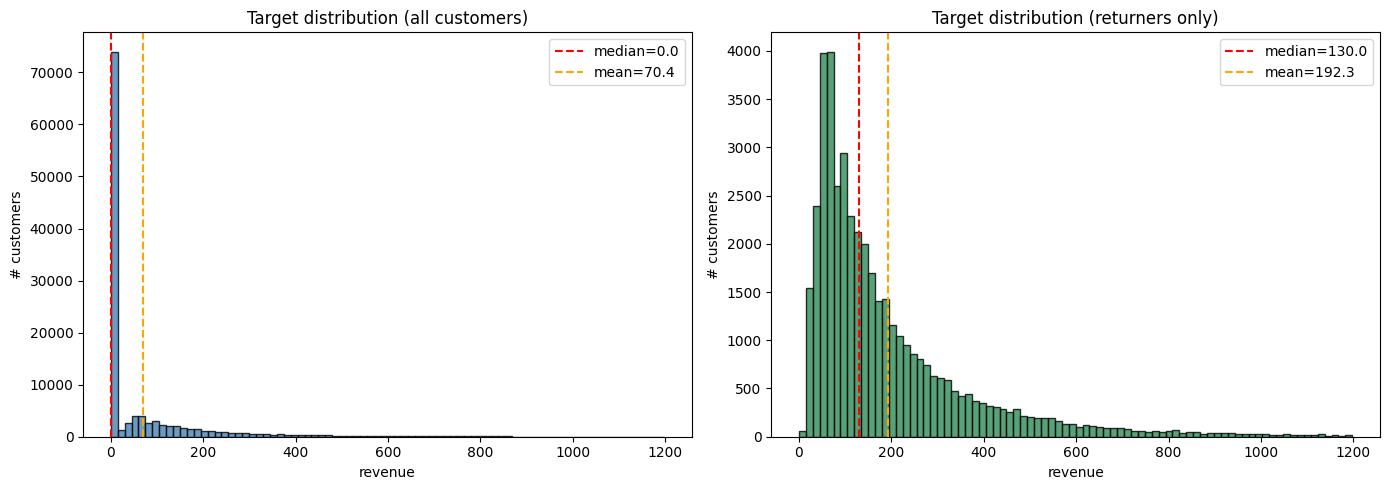

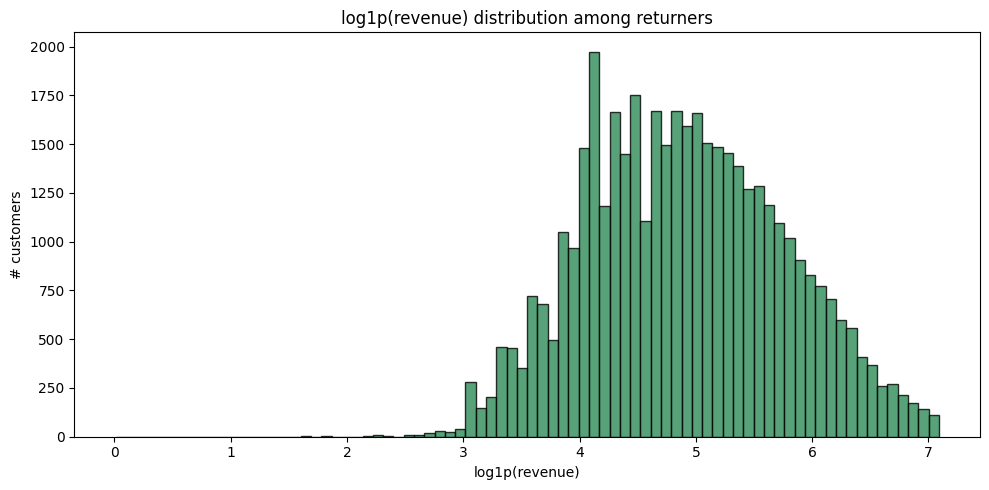

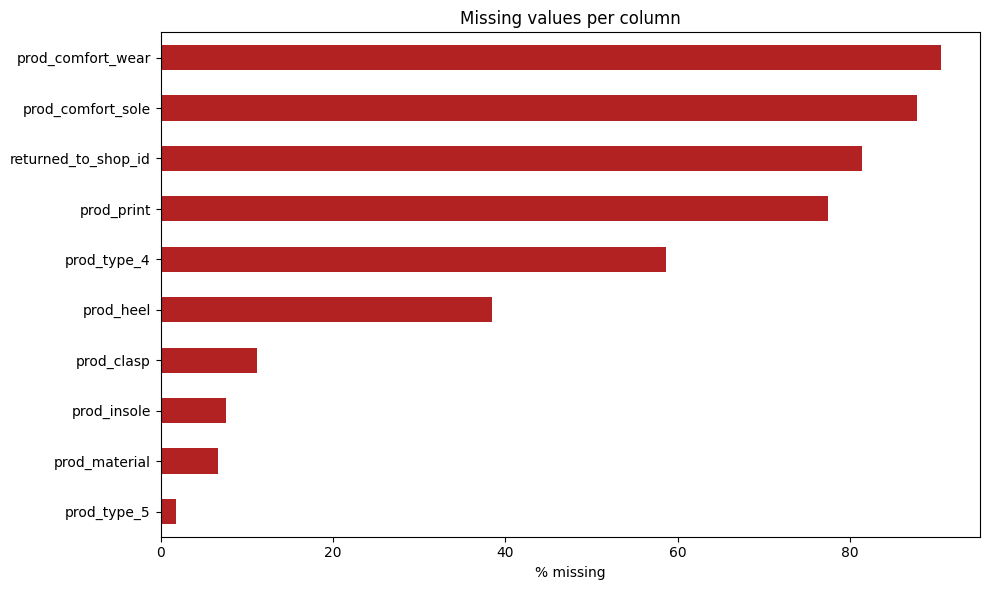

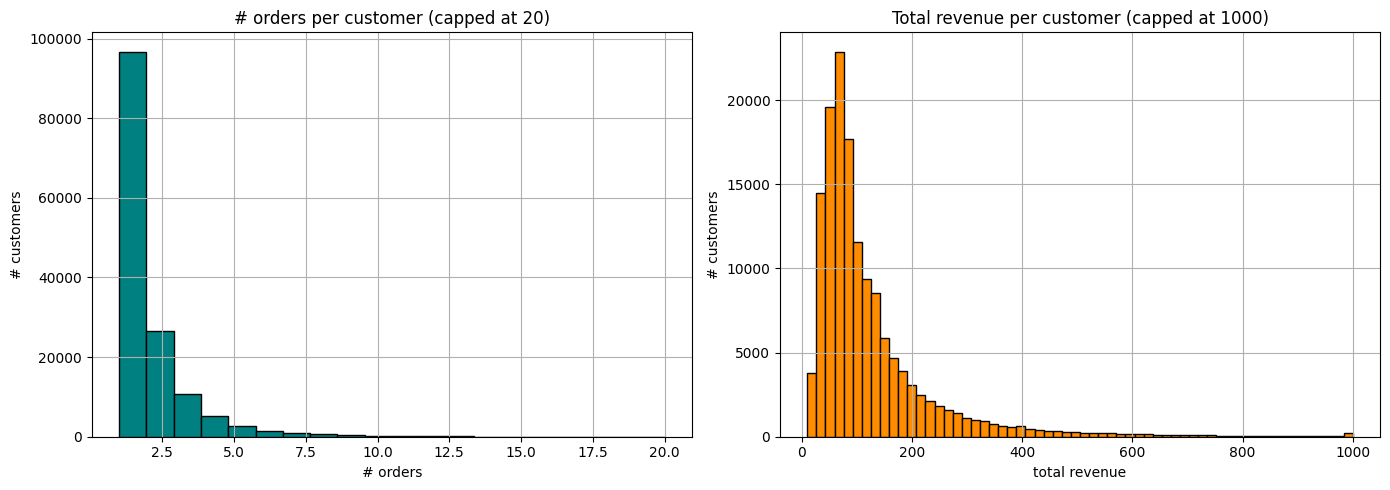

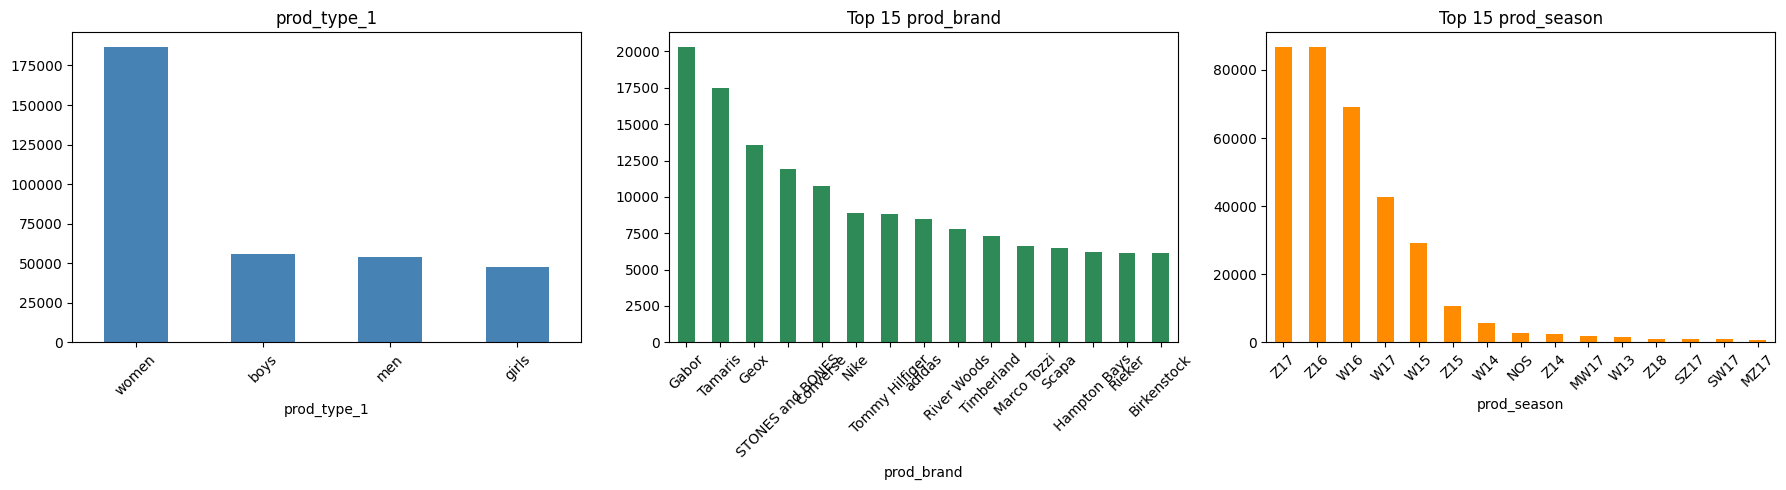

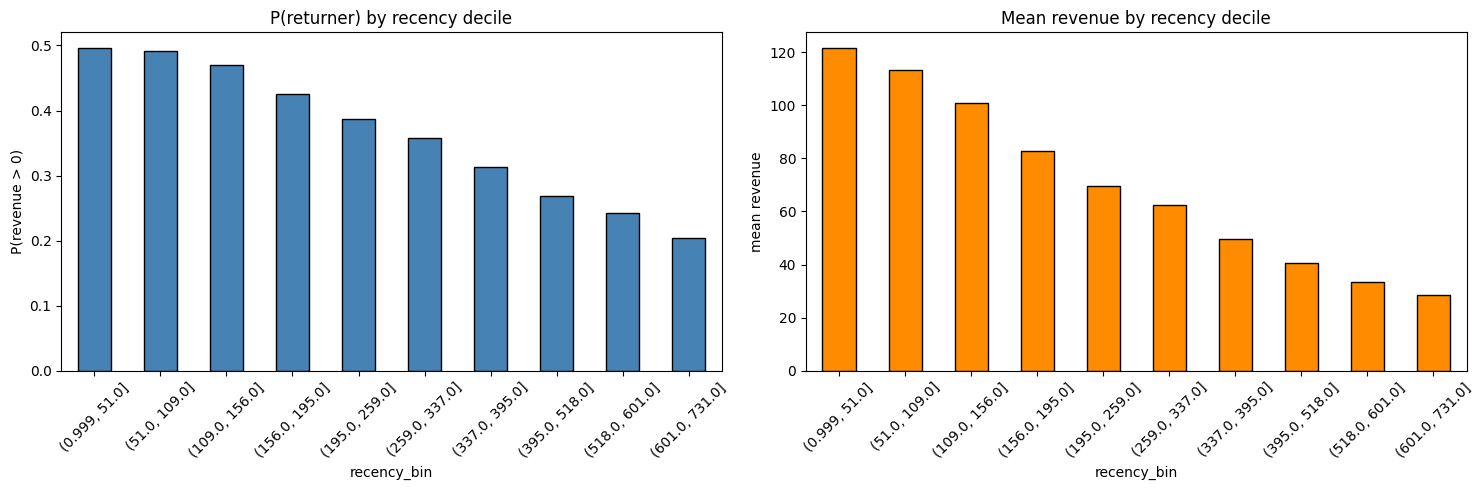

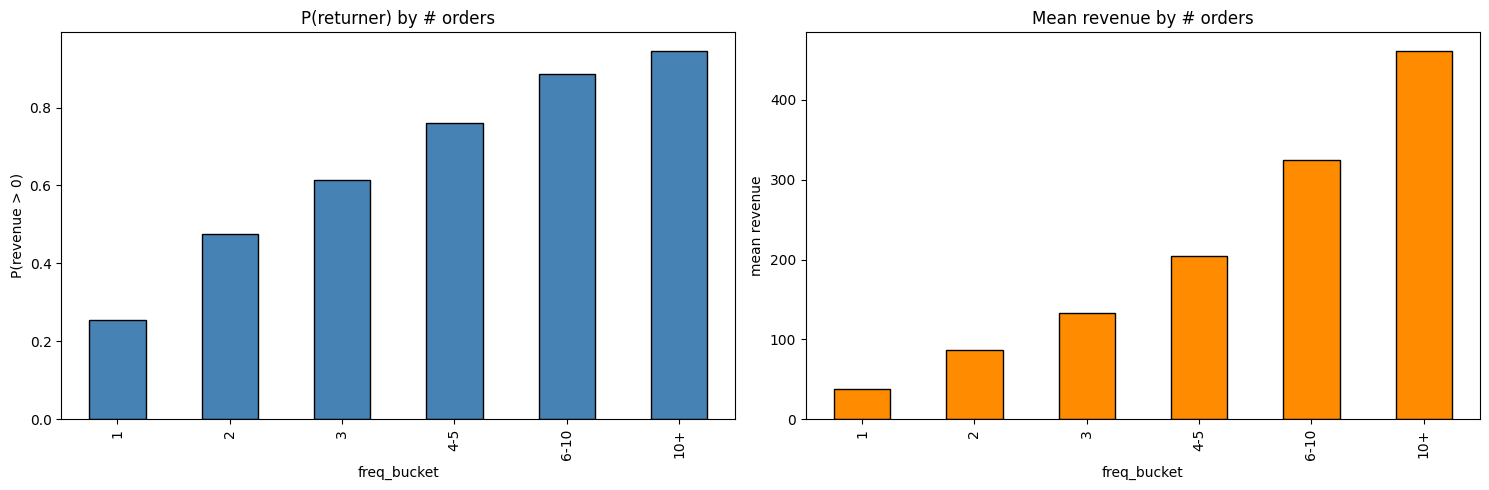

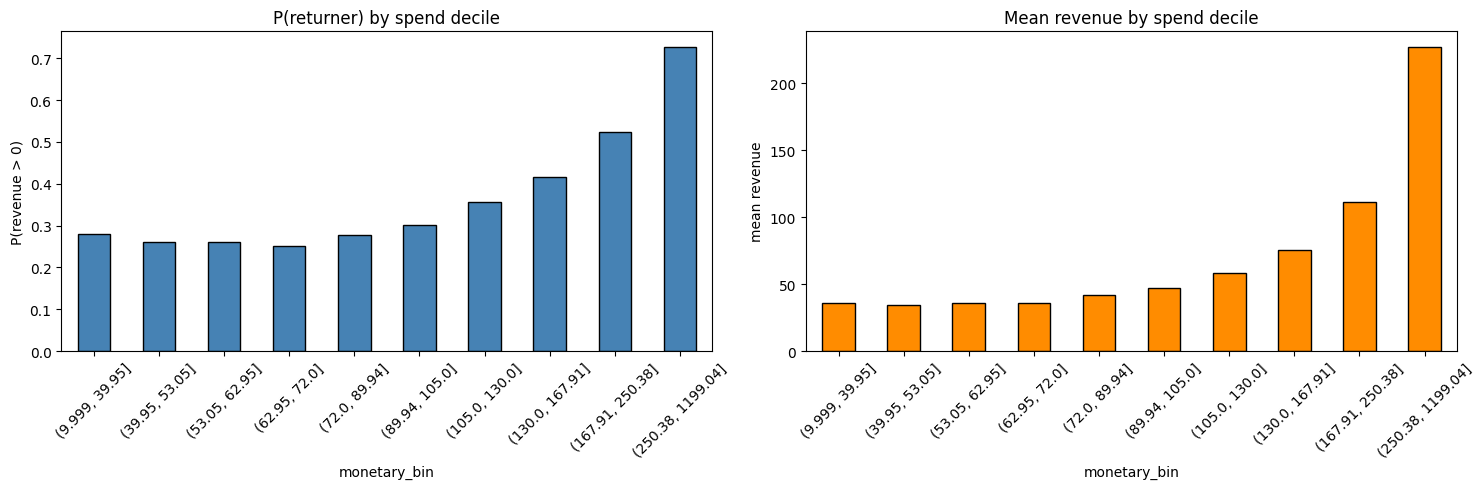

prod_size
top values


prod_size
39.0    44417
38.0    41280
40.0    31834
37.0    26720
41.0    21881
42.0    17001
36.0    15577
43.0    12728
44.0     7803
35.0     7558
28.0     6211
27.0     5971
29.0     5935
33.0     5910
26.0     5881
30.0     5867
31.0     5792
34.0     5776
32.0     5713
45.0     5630
Name: count, dtype: int64

non-numeric values: 1


prod_size
XS    1
Name: count, dtype: int64


prod_comfort_sole
top values


prod_comfort_sole
NaN                                                        302073
pressure relieving                                          14277
pressure relieving, arch support                            11648
anti-shock                                                   4185
arch support                                                 2694
flexible material                                            1856
non-marking soles                                            1544
anti-shock, pressure relieving                               1518
ultralight                                                   1157
memory foam                                                   541
flexible material, ultralight                                 241
pressure relieving, memory foam                               224
non-marking soles, ultralight                                 221
pressure relieving, flexible material                         213
anti-shock, flexible material                             

non-numeric values: 42,139


prod_comfort_sole
pressure relieving                                         14277
pressure relieving, arch support                           11648
anti-shock                                                  4185
arch support                                                2694
flexible material                                           1856
non-marking soles                                           1544
anti-shock, pressure relieving                              1518
ultralight                                                  1157
memory foam                                                  541
flexible material, ultralight                                241
pressure relieving, memory foam                              224
non-marking soles, ultralight                                221
pressure relieving, flexible material                        213
anti-shock, flexible material                                203
pressure relieving, ultralight                               186
anti-sh

In [5]:
eda = run_eda(
    train,
    test,
    transactions,
    paths=paths,
    config=config,
    show_plots=SHOW_PLOTS,
    save_plots=SAVE_PLOTS,
)

for column, details in eda.product_diagnostics.items():
    print(column)
    print("top values")
    display(details["top_values"])
    print(f"non-numeric values: {details['n_non_numeric']:,}")
    display(details["non_numeric_values"])
    print()


### Diagnostic findings: data quality issues identified

Two columns were inferred as object dtype despite having numeric values in the sample data. Investigation revealed:

**1. `prod_size` minor data entry inconsistency**
- The column is basicaly numeric (European shoe sizes: 27.0, 38.0, 39.5, etc.)
- However, **1 row** contains the string `"XS"` instead of a numeric size.
- **Action:** in preprocessing, coerce `prod_size` to numeric using `pd.to_numeric(..., errors="coerce")`, which will turn `"XS"` into `NaN`. The single affected row is negligible.

**2. `prod_comfort_sole` a multi-label categorical**
- this column contains **descriptions of comfort features**, e.g. `"pressure relieving"`, `"anti-shock"`, `"arch support"`, `"memory foam"`, etc.
- 302k rows are missing; among the non-missing rows, **42,139 contain text values**.
- Many entries are **multi-label** (comma-separated), e.g. `"anti-shock, pressure relieving, memory foam, ultralight"` so a single shoe can have multiple comfort features.
- **Action:** treat as categorical. Possible feature engineering directions:
  - Count of comfort features per shoe (0, 1, 2, 3+)
  - Binary indicators for the most common features
  - Aggregate to customer level: e.g. `pct_orders_with_comfort_features`, proxy for whether a customer prefers comfort-oriented shoes.


## 3. Target Variable Analysis

The target is highly zero-inflated and right-skewed. This is the main reason we tried both single-stage models and hurdle-style decompositions later.


In [6]:
print("Target summary")
summary = pd.Series({k: v for k, v in eda.target.items() if k not in {"summary", "positive_quantiles"}})
display(summary)

print("Descriptive statistics")
display(eda.target["summary"])

print("Positive-revenue quantiles")
display(eda.target["positive_quantiles"])

# The plots were produced inside run_eda so the notebook can show and save them consistently.


Target summary


n_customers     116591.00000
n_zero           73933.00000
pct_zero            63.41227
n_positive       42658.00000
pct_positive        36.58773
n_negative           0.00000
dtype: float64

Descriptive statistics


count    116591.000000
mean         70.364667
std         144.303602
min           0.000000
25%           0.000000
50%           0.000000
75%          80.960000
max        1197.940000
Name: revenue_2018_2019, dtype: float64

Positive-revenue quantiles


0.10     44.9600
0.25     69.9500
0.50    129.9700
0.75    246.3600
0.90    429.3850
0.95    570.7300
0.99    917.8294
Name: revenue_2018_2019, dtype: float64

## 4. Transactions Data Quality

This section checks missingness, revenue ranges, discounts, and returns. These checks explain later features such as return rate, revenue lost to returns, discount rate, and missingness indicators.


In [7]:
print("Transaction quality")
display(pd.Series(eda.transaction_quality))

print("Missing values")
display(eda.missing_values.head(25))

sale_revenue = transactions["sale_revenue"]
discount = transactions["sale_discount_applied"]
print(f"sale_revenue == 0: {(sale_revenue == 0).sum():,}")
print(f"sale_revenue < 0: {(sale_revenue < 0).sum():,}")
print(f"returned rows: {transactions['returned_to_shop_id'].notna().sum():,}")
display(sale_revenue.describe().rename("sale_revenue"))
display(discount.describe().rename("sale_discount_applied"))


Transaction quality


n_rows                                                              344212
n_customers                                                         145739
n_orders                                                            245928
n_products                                                           22324
order_date_min                                         2016-01-01 00:00:00
order_date_max                                         2017-12-31 00:00:00
pack_date_min                                          2016-01-03 00:00:00
pack_date_max                                          2018-01-12 00:00:00
sale_revenue             count    344212.000000
mean         53.074974
...
sale_discount_applied    count    344212.000000
mean        -20.646063
...
n_returned_items                                                     63930
dtype: object

Missing values


,n_missing,pct_missing
prod_comfort_wear,311691,90.55
prod_comfort_sole,302073,87.76
returned_to_shop_id,280282,81.43
prod_print,266742,77.49
prod_type_4,201753,58.61
prod_heel,132201,38.41
prod_clasp,38655,11.23
prod_insole,25965,7.54
prod_material,22741,6.61
prod_type_5,6260,1.82


sale_revenue == 0: 60,829
sale_revenue < 0: 2,726
returned rows: 63,930


count    344212.000000
mean         53.074974
std          38.108857
min        -200.000000
25%          27.000000
50%          53.000000
75%          75.950000
max         275.000000
Name: sale_revenue, dtype: float64

count    344212.000000
mean        -20.646063
std          22.479681
min        -200.000000
25%         -31.500000
50%         -12.000000
75%          -4.590000
max           1.000000
Name: sale_discount_applied, dtype: float64

## 5. Customer-Level Statistics

The original customer-level checks showed that most customers had very little purchase history. That matters: complex temporal features can only help a subset of customers.


In [8]:
print("Coverage")
display(pd.Series(eda.coverage))

print("Customer statistics")
display(eda.customer_stats.describe())

one_order = (eda.customer_stats["n_orders"] == 1).mean() * 100
five_plus = (eda.customer_stats["n_orders"] >= 5).mean() * 100
print(f"Customers with exactly 1 order: {one_order:.1f}%")
print(f"Customers with 5+ orders: {five_plus:.1f}%")


Coverage


train_in_transactions    116591
n_train                  116591
test_in_transactions      29148
n_test                    29148
dtype: int64

Customer statistics


,n_rows,n_orders,n_products,total_revenue,first_order,last_order,customer_lifespan_days
count,145739.000000,145739.000000,145739.000000,145739.000000,145739,145739,145739.000000
mean,2.361839,1.687455,2.232944,125.354525,2016-12-11 07:02:56.542997,2017-03-08 14:38:55.545050,87.316655
min,1.000000,1.000000,1.000000,10.000000,2016-01-01 00:00:00,2016-01-01 00:00:00,0.000000
25%,1.000000,1.000000,1.000000,59.300000,2016-06-22 00:00:00,2016-09-28 00:00:00,0.000000
50%,1.000000,1.000000,1.000000,89.900000,2016-12-31 00:00:00,2017-04-17 00:00:00,0.000000
75%,3.000000,2.000000,2.000000,145.250000,2017-06-15 00:00:00,2017-08-15 00:00:00,88.000000
max,142.000000,33.000000,131.000000,1199.040000,2017-12-31 00:00:00,2017-12-31 00:00:00,730.000000
std,2.714648,1.396445,2.446295,119.188366,NaN,NaN,167.318981


Customers with exactly 1 order: 66.4%
Customers with 5+ orders: 4.5%


## 6. Categorical and Product Variables

The product fields are mixed: a few low-cardinality fields, some long-tailed brand/color/material fields, and several heavily missing comfort/detail attributes. The modeling choice later leans on tree models partly because of this structure.


In [9]:
print("Categorical cardinality")
display(eda.categorical["cardinality"])

print("Top brands")
display(eda.categorical["top_brands"])

print("prod_type_1")
display(eda.categorical["prod_type_1"])

print("prod_season")
display(eda.categorical["prod_season"])


Categorical cardinality


,column,n_unique,pct_missing
0,prod_type_1,4,0.000000
1,prod_type_3,41,0.000000
2,prod_type_4,48,58.613006
3,prod_type_5,51,1.818647
4,prod_brand,493,0.000000
5,prod_color,41,0.000000
6,prod_season,23,0.000000
7,prod_heel,4,38.406854
8,prod_material,58,6.606684
9,prod_print,128,77.493521


Top brands


prod_brand
Gabor               20303
Tamaris             17474
Geox                13550
STONES and BONES    11903
Converse            10757
Nike                 8908
Tommy Hilfiger       8794
adidas               8488
River Woods          7795
Timberland           7299
Name: count, dtype: int64

prod_type_1


prod_type_1
women    186636
boys      55828
men       54180
girls     47568
Name: count, dtype: int64

prod_season


prod_season
Z17     86714
Z16     86645
W16     68976
W17     42813
W15     29202
Z15     10530
W14      5660
NOS      2626
Z14      2567
MW17     1984
W13      1642
Z18       921
SZ17      909
SW17      847
MZ17      719
Name: count, dtype: int64

## 7. Predictive Signal Exploration

This was the most useful EDA section in the original notebook. Before building the full feature matrix, a small customer-level table already showed that frequency, historical spend, tenure, and brand diversity are the major signals.


In [10]:
print("Quick feature table")
display(eda.quick_features.head())
print(f"shape: {eda.quick_features.shape}")

print("Correlations with target")
display(eda.quick_signals["correlations"])

print("Returner vs non-returner comparison")
display(eda.quick_signals["returner_comparison"].round(2))


Quick feature table


,cust_id,revenue_2018_2019,n_orders,n_items,total_revenue_1617,mean_revenue,last_order,first_order,total_discount,n_unique_brands,n_returns,recency_days,tenure_days,return_rate,is_returner
0,klantwj2374mzmab,209.85,1,2,83.30,41.650000,2016-01-01,2016-01-01,-75.68,2,1,731,0,0.50,1
1,a63atwr2ig2jfprr,82.93,2,4,53.96,13.490000,2017-06-21,2016-01-01,-64.95,4,3,194,537,0.75,1
2,zr7ihbfbi6gcy2tz,89.95,2,2,83.70,41.850000,2017-01-27,2016-01-01,-66.20,1,0,339,392,0.00,1
3,dt7cthjqnjmkbiu6,0.00,2,4,350.92,87.730000,2017-05-24,2016-01-01,-59.96,4,1,222,509,0.25,0
4,etcrrgcbrzfovyzj,0.00,2,6,144.50,24.083333,2017-01-28,2016-01-01,-715.50,5,3,338,393,0.50,0


shape: (116591, 15)
Correlations with target


total_revenue_1617    0.441262
n_orders              0.434242
n_items               0.412661
n_unique_brands       0.408940
tenure_days           0.362576
n_returns             0.222338
return_rate           0.137560
mean_revenue         -0.046804
recency_days         -0.211561
total_discount       -0.269022
Name: revenue_2018_2019, dtype: float64

Returner vs non-returner comparison


,non_returner,returner,ratio_R_to_NR
n_orders,1.33,2.30,1.72
n_items,1.74,3.43,1.96
total_revenue_1617,98.98,171.18,1.73
mean_revenue,63.90,58.26,0.91
recency_days,330.23,242.65,0.73
tenure_days,45.35,159.87,3.53
total_discount,-35.22,-71.89,2.04
n_unique_brands,1.47,2.59,1.76
n_returns,0.25,0.76,3.01
return_rate,0.07,0.13,1.81


## EDA Summary: Key Findings

### Dataset Overview
- **Transactions**: 344,212 rows covering 145,739 unique customers from 2016-01-01 to 2017-12-31.
- All train (116,591) and test (29,148) customers are present in transactions.
- Average 1.4 items per order (sale_id); 22,324 unique products.

### Target Distribution: Zero-Inflated and Right-Skewed
- **63.4% of customers have revenue = 0** in 2018-2019 (one-time buyers who never returned).
- Among returners (36.6%): median = 130 EUR, mean = 192 EUR, max = 1198 EUR.
- A `log1p` transformation on the returner subset produces a near-symmetric distribution, motivating either a two-stage hurdle model or a Tweedie-style regressor.

### Data Quality Issues
- Heavy missingness appears in product comfort/detail fields.
- Discounts are mostly encoded as negatives: more negative means a larger discount.
- Returns are visible through `returned_to_shop_id`, and return behavior should become explicit features.
- `prod_size` has one non-numeric value; `prod_comfort_sole` is a multi-label categorical text field.

### Customer Behavior
- Most customers are one-time buyers. Inter-purchase intervals and rhythm features are therefore undefined for many rows.
- Frequency and tenure look more useful than average order value.

### Predictive Signal
The strongest quick correlations were historical revenue, number of orders, number of items, brand diversity, tenure, and recency. Mean item/order value was weak by comparison. This shaped the feature design below.


# Feature Engineering: Customer-Level Feature Matrix

We build customer-level features in the same spirit as the original notebook, organized into 11 tiers:

- **Tier 1**: Core RFM + Revenue Quality
- **Tier 2**: Returns Behavior
- **Tier 3**: Discount Behavior
- **Tier 4**: Engagement Flags + log transforms
- **Tier 5**: Time Dynamics + Recent-window
- **Tier 6**: Product Diversity
- **Tier 7**: Gender/Age Preferences
- **Tier 8**: Brand Preferences
- **Tier 9**: Season / Collection
- **Tier 10**: Comfort/Channel + Missingness
- **Tier 11**: Popularity Encoding

Reference date: **2018-01-01** (the day after the feature window ends).

The module now builds these tiers in one call, but the notebook keeps the tier explanation because it is part of the modeling argument.


In [11]:
features, feature_report = build_features(
    train,
    test,
    transactions,
    paths=paths,
    config=config,
    save=SAVE_FEATURES,
)

print("Feature matrix report")
display(pd.Series({k: v for k, v in feature_report.items() if k != "top_nan_pct"}))

print("Top missing-value rates")
display(feature_report["top_nan_pct"].head(20))

display(features.head())


Feature matrix report


shape          (145739, 105)
train_in_fm           116591
n_train               116591
test_in_fm             29148
n_test                 29148
dtype: object

Top missing-value rates


std_inter_purchase_days     84.620452
mean_inter_purchase_days    66.385113
std_prod_size               52.537070
std_item_revenue            52.536384
pct_orders_top15_brand      44.686048
is_premium_brand_buyer      44.686048
is_sport_brand_buyer        44.686048
is_classic_brand_buyer      44.686048
mean_collection_lag          0.593527
mean_collection_year         0.593527
dtype: float64

,n_items,total_revenue,median_item_revenue,max_item_revenue,std_item_revenue,n_unique_brands,n_orders,mean_order_revenue,n_items_per_order,recency_days,first_order_days_ago,tenure_days,gross_revenue,net_to_gross_revenue_ratio,n_returns,n_orders_with_return,revenue_lost_to_returns,return_rate,pct_orders_with_return,total_discount_amt,mean_discount_amt,max_discount_amt,n_discounted_items,pct_items_discounted,discount_rate,log_n_orders,log_total_revenue,is_one_time_buyer,is_repeat_buyer,is_loyal,is_high_value_customer,is_high_frequency_customer,bought_recently,n_active_months,n_active_quarters,revenue_2016,revenue_2017,revenue_trend,revenue_growth_ratio,mean_inter_purchase_days,...,buys_gabor,buys_tamaris,buys_geox,buys_stones__bones,buys_converse,buys_nike,buys_tommy_hilfiger,buys_adidas,buys_river_woods,buys_timberl_,buys_marco_tozzi,buys_scapa,buys_hampton_bays,buys_rieker,buys_birkenstock,n_unique_top_brands,pct_orders_top15_brand,is_premium_brand_buyer,is_sport_brand_buyer,is_classic_brand_buyer,mean_collection_year,n_unique_collection_years,pct_recent_collection,pct_old_stock,mean_collection_lag,n_orders_in_holiday,pct_web_only,mean_outlet,pct_outlet_high,pct_with_comfort_features,pct_with_comfort_wear,missing_prod_heel_rate,missing_prod_clasp_rate,mean_log_brand_popularity,mean_log_product_popularity,rare_brand_item_rate,dominant_type_1_boys,dominant_type_1_girls,dominant_type_1_men,dominant_type_1_women
cust_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
222agnowc53dykbq,1,89.95,89.95,89.95,NaN,1,1,89.95,1.0,384,384,0,89.95,1.000000,0,0,0.0,0.000000,0.0,0.00,0.000000,0.00,0,0.0,0.000000,0.693147,4.510310,1,0,0,0,0,0,1,1,89.95,0.00,-89.95,0.0,NaN,...,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1.0,1.0,0.0,0.0,2016.0,1,0.0,0.0,0.0,1,0.0,0.0,0.0,0.0,1.0,1.000000,0.000000,9.283684,2.397895,0.0,0,0,1,0
222ny4m63rmalpdl,3,125.93,62.96,62.97,36.352860,2,1,125.93,3.0,375,375,0,159.90,0.787555,1,1,0.0,0.333333,1.0,45.16,15.053333,26.98,3,1.0,0.263955,0.693147,4.843636,1,0,0,0,0,0,1,1,125.93,0.00,-125.93,0.0,NaN,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,2016.0,1,0.0,0.0,0.0,1,0.0,0.0,0.0,0.0,0.0,0.666667,0.333333,6.417827,3.661990,0.0,0,0,1,0
222wlefm7esnsi3h,2,157.32,78.66,79.96,1.838478,2,1,157.32,2.0,19,19,0,185.90,0.846261,0,0,0.0,0.000000,0.0,28.58,14.290000,19.99,2,1.0,0.153739,0.693147,5.064618,1,0,0,0,0,1,1,1,0.00,157.32,157.32,20.0,NaN,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,2017.0,1,1.0,0.0,0.0,1,0.0,0.0,0.0,0.0,0.5,0.000000,0.000000,4.619221,2.350240,0.0,0,0,0,1
223jend5smd4ptmc,1,89.95,89.95,89.95,NaN,1,1,89.95,1.0,489,489,0,89.95,1.000000,0,0,0.0,0.000000,0.0,0.00,0.000000,0.00,0,0.0,0.000000,0.693147,4.510310,1,0,0,0,0,0,1,1,89.95,0.00,-89.95,0.0,NaN,...,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1.0,1.0,0.0,0.0,2016.0,1,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,8.855521,3.218876,0.0,0,0,0,1
223xvc4rbjatlnev,2,116.14,58.07,60.17,2.969848,1,1,116.14,2.0,521,521,0,165.90,0.700060,0,0,0.0,0.000000,0.0,49.76,24.880000,25.78,2,1.0,0.299940,0.693147,4.763370,1,0,0,0,0,0,1,1,116.14,0.00,-116.14,0.0,NaN,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,2016.0,1,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.500000,0.500000,8.089482,4.293360,0.0,0,0,0,1


## Feature Matrix Checks

The original notebook spent several cells fixing brand flags and one-hot encoding `dominant_type_1`. Those fixes now happen inside the feature module, so this section verifies the resulting modeling matrix rather than repeating the cleanup code.


In [12]:
object_cols = features.select_dtypes(include="object").columns.tolist()
brand_cols = [c for c in features.columns if c.startswith("buys_")]
dominant_cols = [c for c in features.columns if c.startswith("dominant_type_1_")]

print(f"object columns: {object_cols}")
print(f"brand flag columns: {len(brand_cols)}")
print(f"dominant type columns: {dominant_cols}")
print(f"total features: {len(features.columns)}")

train_features = features.loc[train[config.data.customer_id_col]]
feature_target_corr = train_features.join(
    train.set_index(config.data.customer_id_col)[config.data.target_col]
).corr()[config.data.target_col].drop(config.data.target_col).abs().sort_values(ascending=False)

display(feature_target_corr.head(20))


object columns: []
brand flag columns: 18
dominant type columns: ['dominant_type_1_boys', 'dominant_type_1_girls', 'dominant_type_1_men', 'dominant_type_1_women']
total features: 105


n_active_months               0.442672
total_revenue                 0.441262
n_orders                      0.434242
log_n_orders                  0.429069
n_active_quarters             0.427507
n_unique_products             0.424570
gross_revenue                 0.424503
n_unique_colors               0.421737
n_items                       0.412661
n_unique_brands               0.408940
n_unique_seasons              0.401004
revenue_2017                  0.394209
n_discounted_items            0.382994
n_unique_sizes                0.372326
log_total_revenue             0.368930
is_high_value_customer        0.363249
tenure_days                   0.362576
is_high_frequency_customer    0.337653
n_unique_collection_years     0.327566
is_repeat_buyer               0.321091
Name: revenue_2018_2019, dtype: float64

# Build Train and Test Feature Matrices

From here on, the notebook switches from EDA to modeling. The split is stratified by returner status so the validation set has the same zero/non-zero balance as the full train set.


In [13]:
modeling = prepare_modeling_workflow(features, train, test, config)

print(f"X_train_full shape: {modeling.X_train_full.shape}")
print(f"X_test shape:       {modeling.X_test.shape}")
print()
display(modeling.split_summary)

split_check = pd.DataFrame(
    [
        describe_target(modeling.y_train_full, "Full train"),
        describe_target(modeling.y_train, "Train split"),
        describe_target(modeling.y_val, "Validation split"),
    ]
).set_index("split")
display(split_check)


X_train_full shape: (116591, 105)
X_test shape:       (29148, 105)



,n_customers,pct_returners,mean,median,std,max,p90,p95,p99
split,,,,,,,,,
Full train,116591,36.59%,70.36,0.0,144.30,1197.94,229.94,363.47,704.24
Train (80%),93272,36.59%,70.44,0.0,144.72,1197.94,229.95,364.35,707.54
Validation (20%),23319,36.59%,70.05,0.0,142.62,1194.65,229.64,359.90,698.10


,n_customers,pct_returners,mean,median,std,max,p90,p95,p99
split,,,,,,,,,
Full train,116591,36.59%,70.36,0.0,144.30,1197.94,229.94,363.47,704.24
Train split,93272,36.59%,70.44,0.0,144.72,1197.94,229.95,364.35,707.54
Validation split,23319,36.59%,70.05,0.0,142.62,1194.65,229.64,359.90,698.10


# Baseline Models

The baseline section has two purposes. Group A tells us what happens if we use no features. Group B uses standard course methods and gives a sensible benchmark before XGBoost.


In [14]:
if RUN_COURSE_BASELINES:
    baseline_results = run_baseline_models(modeling, config)
    display(baseline_results)
else:
    baseline_results = pd.DataFrame()
    print("Course baselines skipped.")


,group,model,MAE,Spearman
0,B. Course methods,B1b. Ridge on log1p(y),64.756235,0.395674
1,A. Sanity,A1. Predict 0 for everyone,70.054004,NaN
2,A. Sanity,A3. Predict median,70.054004,NaN
3,B. Course methods,B1. Ridge Regression,76.857276,0.391415
4,B. Course methods,B4. Random Forest,77.020723,0.392928
5,B. Course methods,B2. Decision Tree,77.860900,0.383468
6,B. Course methods,B3. KNN,78.888809,0.328363
7,A. Sanity,A2. Predict mean,92.996936,NaN


## Group A Reflection

The median of the target is zero, so predicting the median and predicting zero are the same baseline. This is a useful reminder: with a zero-inflated target, MAE rewards being conservative. Mean prediction does worse because it assigns positive revenue to too many non-returners.


# Group C: Main Models

The first main trial group from the original notebook used XGBoost in three forms:

- **C1**: single regression model optimized for MAE
- **C2**: Tweedie model for zero-inflated positive targets
- **C3**: two-stage hurdle model, classification first and conditional revenue second

The expectation was that C2 or C3 might handle zero inflation better. The actual validation results favored C1.


In [15]:
if RUN_XGBOOST_MODELS:
    main_run = run_main_models(modeling, config, include_extended=RUN_EXTENDED_XGBOOST)
    all_results = results_frame(
        baseline_results.to_dict("records") + main_run.results.to_dict("records")
    ) if not baseline_results.empty else main_run.results
    display(all_results)
else:
    main_run = None
    all_results = baseline_results.copy()
    print("XGBoost models skipped.")


,group,model,MAE,Spearman
0,C. Main,C1. XGBoost single regression,62.018224,0.403423
1,D. Long-tail,D3. XGBoost Pseudo-Huber,62.466986,0.387353
2,D. Long-tail,D2. XGBoost log1p MSE,64.548734,0.402921
3,B. Course methods,B1b. Ridge on log1p(y),64.756235,0.395674
4,A. Sanity,A1. Predict 0 for everyone,70.054004,NaN
5,A. Sanity,A3. Predict median,70.054004,NaN
6,C. Main,C3. Two-stage hurdle,71.167291,0.401066
7,C. Main,C2. XGBoost Tweedie,73.340972,0.385308
8,B. Course methods,B1. Ridge Regression,76.857276,0.391415
9,B. Course methods,B4. Random Forest,77.020723,0.392928


## Prediction Distribution Diagnostic

The original notebook then inspected prediction distributions. This is where the model behavior became clearer: the best MAE model was very conservative, while the hurdle variants tended to predict positive revenue too often.


In [16]:
if main_run is not None:
    display(prediction_distribution_table(main_run.predictions, PREDICTION_DISTRIBUTION_CUTOFFS).round(2))
    if "xgb_c1" in main_run.predictions:
        display(error_decomposition(
            modeling.y_val,
            main_run.predictions["xgb_c1"],
            config.eda.positive_target_threshold,
        ).round(2))
else:
    print("No main model predictions available.")


,min,median,mean,max,pct_zero,pct_lt_5,pct_lt_20
model,,,,,,,
xgb_c1,0.00,0.00,25.61,532.64,64.79,69.92,75.36
xgb_c2,0.27,35.16,60.55,747.16,0.00,1.28,20.55
hurdle,6.65,30.10,52.99,572.89,0.00,0.00,21.18
xgb_d1,13.71,41.22,70.89,689.65,0.00,0.00,1.02
xgb_d2,0.34,2.73,14.68,539.28,0.00,64.75,85.64
xgb_d3,0.00,0.39,26.81,427.17,1.59,68.57,75.42


mae_true_zero                    9.77
mae_true_positive              152.57
error_contribution_zero          6.20
error_contribution_positive     55.82
dtype: float64

# Group C v2: Improved Main Models

Based on the first diagnostics, the original notebook tried stronger XGBoost variants: a deeper MAE model, Tweedie powers closer to Gamma behavior, and a stronger two-stage hurdle. These were useful trials even though they did not replace C1.


In [17]:
if RUN_IMPROVED_XGBOOST_TRIALS:
    improved_run = run_improved_xgboost_trials(
        modeling.X_train,
        modeling.X_val,
        modeling.y_train,
        modeling.y_val,
        config.modeling,
        trial_params=IMPROVED_XGB_PARAMS,
        tweedie_powers=TWEEDIE_TRIAL_POWERS,
    )
    all_results = results_frame(all_results.to_dict("records") + improved_run.results.to_dict("records"))
    display(improved_run.results)
else:
    improved_run = None
    print("Improved XGBoost trials skipped.")


,group,model,MAE,Spearman
0,C. Main v2,C1.v2 XGBoost MAE (deeper),62.078031,0.395858
1,C. Main v2,C2.v Tweedie (power=1.7),69.017993,0.354635
2,C. Main v2,C2.v Tweedie (power=1.8),69.091279,0.357447
3,C. Main v2,C3.v2 Two-stage hurdle,71.254111,0.400977


## Feature Importance and Prediction-Bin Variance

After C1 emerged as the strongest model, the original notebook inspected feature importance and the spread of actual revenue inside prediction bins. This helped explain why predicting large future revenue remains hard: even among similar predicted customers, actual outcomes vary a lot.


In [18]:
if main_run is not None and "xgb_c1" in main_run.artifacts:
    fi = feature_importance_table(main_run.artifacts["xgb_c1"], modeling.X_train.columns, top_n=20)
    display(fi)
    display(variance_by_prediction_bin(
        modeling.y_val,
        main_run.predictions["xgb_c1"],
        config.eda.positive_target_threshold,
        q=10,
    ).round(1))
else:
    print("C1 model not available.")


,feature,importance
0,tenure_days,0.162272
1,n_orders,0.126167
2,n_active_months,0.078961
3,mean_inter_purchase_days,0.076310
4,n_active_quarters,0.039972
5,n_items,0.039854
6,n_unique_products,0.023175
7,buys_stones__bones,0.022521
8,revenue_2017,0.012145
9,n_items_per_order,0.011835


,mean,std,count
pred_bin,,,
"(-0.001, 7.483]",147.9,133.3,4266
"(7.483, 30.399]",156.1,139.8,853
"(30.399, 57.076]",192.6,166.5,853
"(57.076, 93.255]",212.8,175.7,853
"(93.255, 163.149]",230.4,186.5,853
"(163.149, 532.635]",383.3,268.8,854


# Outlier and Long-Tail Diagnostics

The next question was whether MAE is dominated by high-value customers. The original result was clear: a small share of customers with actual revenue above 200 EUR contributed a large share of total absolute error.


In [19]:
if main_run is not None and "xgb_c1" in main_run.predictions:
    c1_pred = main_run.predictions["xgb_c1"]
    display(error_by_actual_thresholds(
        modeling.y_val,
        c1_pred,
        ACTUAL_REVENUE_THRESHOLDS,
    ).round(2))
    display(calibration_by_actual_bins(
        modeling.y_val,
        c1_pred,
        ACTUAL_REVENUE_BINS,
    ).round(1))
else:
    print("C1 predictions not available.")


,threshold,n_above,pct_above,error_sum,pct_total_error,mae_if_excluded
0,200,2749,11.79,835152.24,57.75,29.71
1,300,1605,6.88,616872.52,42.65,38.19
2,500,601,2.58,322287.46,22.29,49.47
3,700,230,0.99,157976.47,10.92,55.79
4,1000,42,0.18,35881.71,2.48,60.59


,n,actual_mean,pred_mean,pred_max
actual_bin,,,,
"(-1.001, 0.0]",14787,0.0,9.8,421.8
"(0.0, 50.0]",1067,36.8,27.7,408.1
"(50.0, 100.0]",2288,73.1,28.9,487.1
"(100.0, 200.0]",2428,144.1,41.6,439.4
"(200.0, 300.0]",1144,244.3,62.8,508.1
"(300.0, 500.0]",1004,380.4,90.3,474.8
"(500.0, 700.0]",371,581.1,138.3,512.4
"(700.0, 2000.0]",230,870.4,183.6,532.6


## Group D: Long-Tail Aware Models

The original notebook tried MSE, log-MSE, and pseudo-Huber XGBoost variants to see whether long-tail customers could be better handled. These models improved some intuitions about the tail but did not beat the MAE-optimized C1 on validation MAE.


In [20]:
if main_run is not None and RUN_EXTENDED_XGBOOST:
    long_tail_rows = main_run.results[main_run.results["group"].eq("D. Long-tail")]
    display(long_tail_rows)
else:
    print("Long-tail model trials skipped or unavailable.")


,group,model,MAE,Spearman
1,D. Long-tail,D3. XGBoost Pseudo-Huber,62.466986,0.387353
2,D. Long-tail,D2. XGBoost log1p MSE,64.548734,0.402921
5,D. Long-tail,D1. XGBoost MSE,77.119940,0.397234


## Why High Values Are Difficult

The original root-cause diagnostic compared top-revenue customers with the rest. Top customers had more items, more orders, more active months, longer tenure, more brands, and more products. The signal exists, but the remaining variance is large.


In [21]:
comparison_features = [
    "n_items",
    "n_orders",
    "total_revenue",
    "n_active_months",
    "tenure_days",
    "n_unique_brands",
    "n_unique_products",
]
available_comparison_features = [c for c in comparison_features if c in modeling.X_train_full.columns]
comparison, top_threshold = high_value_feature_comparison(
    modeling.X_train_full,
    modeling.y_train_full,
    available_comparison_features,
    quantile=0.99,
)
print(f"Top 1% threshold: {top_threshold:.0f} EUR")
display(comparison.round(2))


Top 1% threshold: 704 EUR


,feature,top_mean,rest_mean,ratio
0,n_items,8.13,2.30,3.53
1,n_orders,4.66,1.66,2.81
2,total_revenue,408.41,122.54,3.33
3,n_active_months,3.85,1.51,2.54
4,tenure_days,320.38,84.90,3.77
5,n_unique_brands,5.26,1.84,2.85
6,n_unique_products,7.54,2.18,3.46


# Group E: Multi-Tier Hurdle Model

The original notebook tried a more explicit multi-tier architecture: returner probability, high-value probability among returners, and separate revenue models for low and high returners. The result was informative but not competitive. It predicted larger values, but at the cost of too many false positives and worse MAE.

Rather than rerunning that large experimental branch here, the notebook keeps the conclusion and focuses the executable path on the variants used for the final decision.


# MAE-Aligned Hurdle and C1 Post-Processing

The most useful later experiment was not a more complex hurdle, but an MAE-aligned adjustment: either threshold return probability in a hurdle model, or zero out very small C1 predictions. The latter became the final champion because it improved MAE slightly without changing the model architecture.


In [22]:
if RUN_MAE_ALIGNED_HURDLE:
    mae_hurdle_run = run_mae_aligned_hurdle(
        modeling.X_train,
        modeling.X_val,
        modeling.y_train,
        modeling.y_val,
        config.modeling,
        params=MAE_HURDLE_PARAMS,
        probability_thresholds=MAE_HURDLE_PROB_THRESHOLDS,
    )
    display(mae_hurdle_run.artifacts["threshold_table"].round(3))
    all_results = results_frame(all_results.to_dict("records") + mae_hurdle_run.results.to_dict("records"))
else:
    mae_hurdle_run = None
    print("MAE-aligned hurdle skipped.")

if main_run is not None and "xgb_c1" in main_run.predictions:
    c1_zeroing = zero_threshold_table(
        main_run.predictions["xgb_c1"],
        modeling.y_val,
        config.modeling.zero_threshold_grid,
    )
    display(c1_zeroing.round(4))
else:
    c1_zeroing = pd.DataFrame()
    print("C1 post-processing skipped because C1 predictions are unavailable.")


,threshold,MAE,Spearman,pct_zero
8,0.60,63.912,0.380,84.493
7,0.55,64.424,0.395,80.702
6,0.50,65.443,0.405,76.427
5,0.45,66.941,0.410,72.027
4,0.40,68.858,0.413,67.096
3,0.35,71.514,0.407,61.885
2,0.30,76.017,0.395,54.093
1,0.25,84.665,0.385,38.621
0,0.20,98.122,0.364,17.711


,threshold,mae,spearman,extra_zeros,is_best
0,0.0,62.0182,0.4034,0,False
1,0.5,62.0173,0.4063,265,False
2,1.0,62.0155,0.4079,398,False
3,2.0,62.0090,0.4098,714,False
4,3.0,62.0025,0.4112,908,False
5,5.0,61.9969,0.4099,1195,False
6,7.0,61.9899,0.4093,1383,False
7,10.0,61.9715,0.4107,1632,False
8,15.0,61.9511,0.4095,2044,False
9,20.0,61.9354,0.4079,2465,True


## Updated Validation Leaderboard

This table collects the validation results from the executable model trials in this notebook. The original conclusion was that C1 with small-value zeroing is the best practical choice: simple, stable, and backed by cross-validation.


In [23]:
display(all_results.sort_values("MAE"))


,group,model,MAE,Spearman
0,C. Main,C1. XGBoost single regression,62.018224,0.403423
1,C. Main v2,C1.v2 XGBoost MAE (deeper),62.078031,0.395858
2,D. Long-tail,D3. XGBoost Pseudo-Huber,62.466986,0.387353
3,F. MAE,F1. MAE-aligned hurdle (t=0.6),63.911603,0.379800
4,F. MAE,F1. MAE-aligned hurdle (t=0.55),64.424175,0.395144
5,D. Long-tail,D2. XGBoost log1p MSE,64.548734,0.402921
6,B. Course methods,B1b. Ridge on log1p(y),64.756235,0.395674
7,F. MAE,F1. MAE-aligned hurdle (t=0.5),65.443044,0.405481
8,F. MAE,F1. MAE-aligned hurdle (t=0.45),66.941325,0.409964
9,F. MAE,F1. MAE-aligned hurdle (t=0.4),68.857887,0.412529


# Cross-Validation on Champion Model

The original single validation split was slightly optimistic, so the champion was checked with 5-fold stratified cross-validation. The purpose was to get both a more reliable MAE estimate and a sense of split-to-split variation.


In [24]:
if RUN_CROSS_VALIDATION:
    cv_results = run_champion_cv(
        modeling,
        config,
        n_splits=config.modeling.champion_n_splits,
        zero_threshold=config.modeling.champion_zero_threshold,
    )
    display(cv_results)
    display(cv_results[["mae_raw", "mae_post_processed", "spearman_post_processed"]].agg(["mean", "std"]))
else:
    cv_results = pd.DataFrame()
    print("Cross-validation skipped.")


,fold,n_train,n_val,mae_raw,mae_post_processed,spearman_post_processed,seconds
0,1,93272,23319,62.132947,62.031424,0.408215,4.578402
1,2,93273,23318,63.537092,63.396490,0.415136,4.204556
2,3,93273,23318,62.189915,62.033381,0.412479,3.362900
3,4,93273,23318,61.742384,61.686253,0.404997,2.627139
4,5,93273,23318,61.940231,61.888739,0.397172,3.554881


,mae_raw,mae_post_processed,spearman_post_processed
mean,62.308514,62.207257,0.407600
std,0.708948,0.679766,0.007009


# Generate Submission Files

The original notebook saved three submission variants:

- `v01`: champion XGBoost MAE with small-value zeroing
- `v02`: ensemble backup
- `v03`: hurdle-style architectural backup

The package currently writes the champion file directly. The backup variants are still discussed because they were part of the project history and leaderboard comparison.


In [25]:
if RUN_SUBMISSIONS:
    submission_paths = generate_submission_files(
        modeling,
        test,
        paths=paths,
        config=config,
        zero_threshold=config.modeling.champion_zero_threshold,
    )
    print("Generated submission files")
    display(pd.Series(submission_paths))

    champion_submission = pd.read_csv(submission_paths["champion"])
    display(submission_summary({"v01_champion": champion_submission}, config.data.prediction_col).round(2))
else:
    submission_paths = {}
    print("Submission generation skipped.")


Generated submission files


champion    /Users/xinran_joyce/Desktop/KU Leuven/Courses ...
dtype: object

,mean,median,max,pct_zero,n_rows
submission,,,,,
v01_champion,25.07,0.0,547.69,76.85,29148


### Public Leaderboard Submissions and Comparative Analysis

We submitted three architectural variants to the leaderboard, with v01 (our cross-validation champion) designated as the final answer prior to any leaderboard feedback. Cross-validation was performed on the champion only; v02 and v03 were assessed via the same 80/20 validation split used throughout model development.

| Submission | Architecture                                     | Validation MAE     | Public MAE | Public Spearman | Rank |
|------------|--------------------------------------------------|--------------------|------------|-----------------|------|
| v01        | XGBoost MAE + post-processing (zero<25)          | 62.23 ± 0.22 (CV)  | 61.596     | 0.414           | 12   |
| v02        | Equal-weight ensemble (C1, C1.v2, D3)            | not reported       | 61.633     | 0.414           | 14   |
| v03        | MAE-aligned Hurdle (P(ret)>0.6 → median)         | 63.89 (val split)  | 63.481     | 0.386           | 27   |

Three findings emerged from this comparison:

**Finding 1: v02 ensemble provided no meaningful gain over v01.** The 0.037 EUR public MAE difference is well within our CV standard deviation (0.22 EUR), and the Spearman correlations are identical (0.414). This is consistent with the fact that all three averaged models are XGBoost variants with high prediction correlation.

**Finding 2: The Public leaderboard score for v03 closely matched its single-split validation MAE.** This validated that the MAE-aligned hurdle architecture was genuinely worse than single-stage XGBoost MAE, not just unlucky on one split.

**Finding 3: The champion is competitive with the top performers.** The gap to rank 1 was small relative to the tight spread among serious models.

**Final submission:** v01 was re-uploaded as the final entry on the public leaderboard.


# Final Checks

These are the same compact final numbers from the original notebook, kept here so the project summary can be checked quickly after a run.


In [ ]:
target = modeling.y_train_full
positive_target = target[target > config.eda.positive_target_threshold]
print(f"Train rows: {len(train):,}")
print(f"Test rows: {len(test):,}")
print(f"Transactions rows: {len(transactions):,}")
print(f"Unique customers in transactions: {transactions[config.data.customer_id_col].nunique():,}")
print()
print(f"Zero rate in train: {(target == config.eda.positive_target_threshold).mean()*100:.2f}%")
print(f"Returner mean: {positive_target.mean():.2f}")
print(f"Returner median: {positive_target.median():.2f}")
print(f"Returner max: {positive_target.max():.2f}")
print()
print(f"X_train_full shape: {modeling.X_train_full.shape}")
print(f"Total features: {len(features.columns)}")
